# v3 binary MLP confidence -> DCASE baseline

`v3` is originally a binary model for `confidence >= 4`. To run the requested `>=2`, `>=3`, `>=4` downstream grid, its high-confidence probability is converted to a 1-5 pseudo confidence score with `1 + 4 * probability`.

As required, scores are merged only into `train_pool`; the fixed `final_test 20%` is never filtered.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if not (HERE / 'confidence_baseline_common.py').exists():
    sys.path.insert(0, str(HERE / 'baseline_confidnce_train'))
else:
    sys.path.insert(0, str(HERE))

from confidence_baseline_common import ROOT, load_prediction_csv, run_downstream_grid, confidence_threshold_specs, load_baseline_assets, make_fixed_holdout

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64

OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v3_binary'
full_df, _, _ = load_baseline_assets(ROOT)
train_pool, final_test, _ = make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED)

score_df = load_prediction_csv(ROOT / 'outputs' / 'confidence_filter_v3' / 'predictions' / 'BSD10k_oof_binary_mlp.csv')
score_df = score_df[score_df['sound_id'].isin(set(train_pool['index'].astype(str)))].copy()
score_df = score_df[['sound_id', 'predicted_high_confidence_prob']].copy()
score_df['predicted_confidence_score'] = 1.0 + 4.0 * score_df['predicted_high_confidence_prob'].astype(float)
score_df.head()

,sound_id,predicted_high_confidence_prob,predicted_confidence_score
0,185755,0.599564,3.398254
3,432206,0.619771,3.479082
4,80630,0.960568,4.842271
6,145544,0.417653,2.670612
7,156796,0.391700,2.566802


In [2]:
summary, filter_counts = run_downstream_grid(
    experiment_name='v3_binary_prob_scaled_to_1_5',
    score_df=score_df,
    output_root=OUTPUT_ROOT,
    score_col='predicted_confidence_score',
    threshold_specs=confidence_threshold_specs([2, 3, 4]),
    baseline_modes=BASELINE_MODES,
    use_kfold=USE_KFOLD,
    n_folds=N_FOLDS,
    seed=SEED,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
)
display(filter_counts)
summary


=== Filter counts ===
filter_label               score_column  threshold  display_threshold  train_pool_samples  retained_samples  dropped_samples  retained_ratio  num_classes_retained
   pred_ge_2 predicted_confidence_score        2.0                  2                8764              8100              664        0.924236                    23
   pred_ge_3 predicted_confidence_score        3.0                  3                8764              6050             2714        0.690324                    23
   pred_ge_4 predicted_confidence_score        4.0                  4                8764              3048             5716        0.347786                    21

=== Downstream baseline plan ===
experiment=v3_binary_prob_scaled_to_1_5
device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
baseline_modes=('both',)
use_kfold=True, n_folds=5
thresholds=[2, 3, 4]
planned_trainings=15
num_epochs=100, batch_size=64

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.29%
[BaseClassifier | Fold final_test] Top class accuracy: 89.42%
[BaseClassifier | Fold final_test] Macro accuracy: 74.38%
[BaseClassifier | Fold final_test] Macro top class accuracy: 85.60%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.99%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.51%
[BaseClassifier | Fold final_test] Hierarchical recall: 78.58%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.83%
  completed in 9.1 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_2\both\fold_1
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=6480, val=1620, final_test=2192
  batches: train=101, val=26, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 59.94%
  New best model saved
Epoch [2/100] - Val acc: 72.35%
  New best model saved
Epoch [3/100] - Val acc: 76.42%
  New best model saved
Epoch [4/100] - Val acc: 79.20%
  New be

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.66%
[BaseClassifier | Fold final_test] Top class accuracy: 89.32%
[BaseClassifier | Fold final_test] Macro accuracy: 74.48%
[BaseClassifier | Fold final_test] Macro top class accuracy: 85.14%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.81%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.44%
[BaseClassifier | Fold final_test] Hierarchical recall: 78.48%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.72%
  completed in 8.3 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_2\both\fold_2
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=6480, val=1620, final_test=2192
  batches: train=101, val=26, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 59.38%
  New best model saved
Epoch [2/100] - Val acc: 70.31%
  New best model saved
Epoch [3/100] - Val acc: 73.83%
  New best model saved
Epoch [4/100] - Val acc: 75.25%
  New be

...

[BaseClassifier | Fold final_test] Accuracy: 66.24%
[BaseClassifier | Fold final_test] Top class accuracy: 79.79%
[BaseClassifier | Fold final_test] Macro accuracy: 57.76%
[BaseClassifier | Fold final_test] Macro top class accuracy: 74.15%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 65.95%
[BaseClassifier | Fold final_test] Hierarchical precision: 66.26%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.58%
[BaseClassifier | Fold final_test] Hierarchical F1: 67.89%
  completed in 2.4 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_4\both\fold_4
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=2439, val=609, final_test=2192
  batches: train=38, val=10, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 30.05%
  New best model saved
Epoch [2/100] - Val acc: 86.70%
  New best model saved
Epoch [3/100] - Val acc: 87.52%
  New best model saved
Epoch [4/100] - Val acc: 88.34%
  New best

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 67.52%
[BaseClassifier | Fold final_test] Top class accuracy: 81.02%
[BaseClassifier | Fold final_test] Macro accuracy: 59.23%
[BaseClassifier | Fold final_test] Macro top class accuracy: 76.08%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 67.66%
[BaseClassifier | Fold final_test] Hierarchical precision: 71.26%
[BaseClassifier | Fold final_test] Hierarchical recall: 73.78%
[BaseClassifier | Fold final_test] Hierarchical F1: 68.64%
  completed in 2.4 min


,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,dropped_samples,retained_ratio,num_classes_retained
0,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,664,0.924236,23
1,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,2714,0.690324,23
2,pred_ge_4,predicted_confidence_score,4.0,4,8764,3048,5716,0.347786,21


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,80.370370,80.291971,89.416058,74.375116,85.596959,79.986037,79.512542,78.583307,78.830827,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,82.777778,80.656934,89.324818,74.481837,85.141587,79.811712,79.438483,78.479243,78.718453,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,81.604938,80.063869,88.731752,73.243288,84.369761,78.806524,78.341249,77.415715,77.607351,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,81.358025,79.653285,89.233577,74.030321,85.292895,79.661608,79.227172,78.253786,78.101764,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,81.604938,79.333942,89.279197,72.012755,84.383428,78.198092,78.935513,76.651758,77.024585,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,87.685950,76.186131,86.678832,70.287527,82.842138,76.564833,75.937042,74.995506,74.362184,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,87.355372,76.231752,86.541971,69.045117,81.848055,75.446586,74.099654,73.846219,73.436455,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,87.272727,77.144161,86.633212,69.138638,81.766566,75.452602,75.243512,73.874111,73.770485,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,88.760331,76.003650,86.724453,68.886235,82.466413,75.676324,74.351231,73.978801,73.317713,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,86.694215,75.593066,86.222628,68.506948,81.587106,75.047027,75.346675,73.412007,73.016980,c:\Users\solok\Desktop\Dcase baseline\baseline...



=== All downstream run results ===
source: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\summary_results.csv
saved view: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\all_run_results_view.csv
filter_label  threshold  retained_samples  retained_ratio mode  split  train_samples  val_samples  final_test_samples  best_val_accuracy  accuracy  top_accuracy  macro_accuracy  hierarchical_accuracy  hierarchical_precision  hierarchical_recall  hierarchical_f1                                                                                             output_dir
   pred_ge_2        2.0              8100        0.924236 both fold_0           6480         1620                2192          80.370370 80.291971     89.416058       74.375116              79.986037               79.512542            78.583307        78.830827 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_2\both\fold_0
   pred

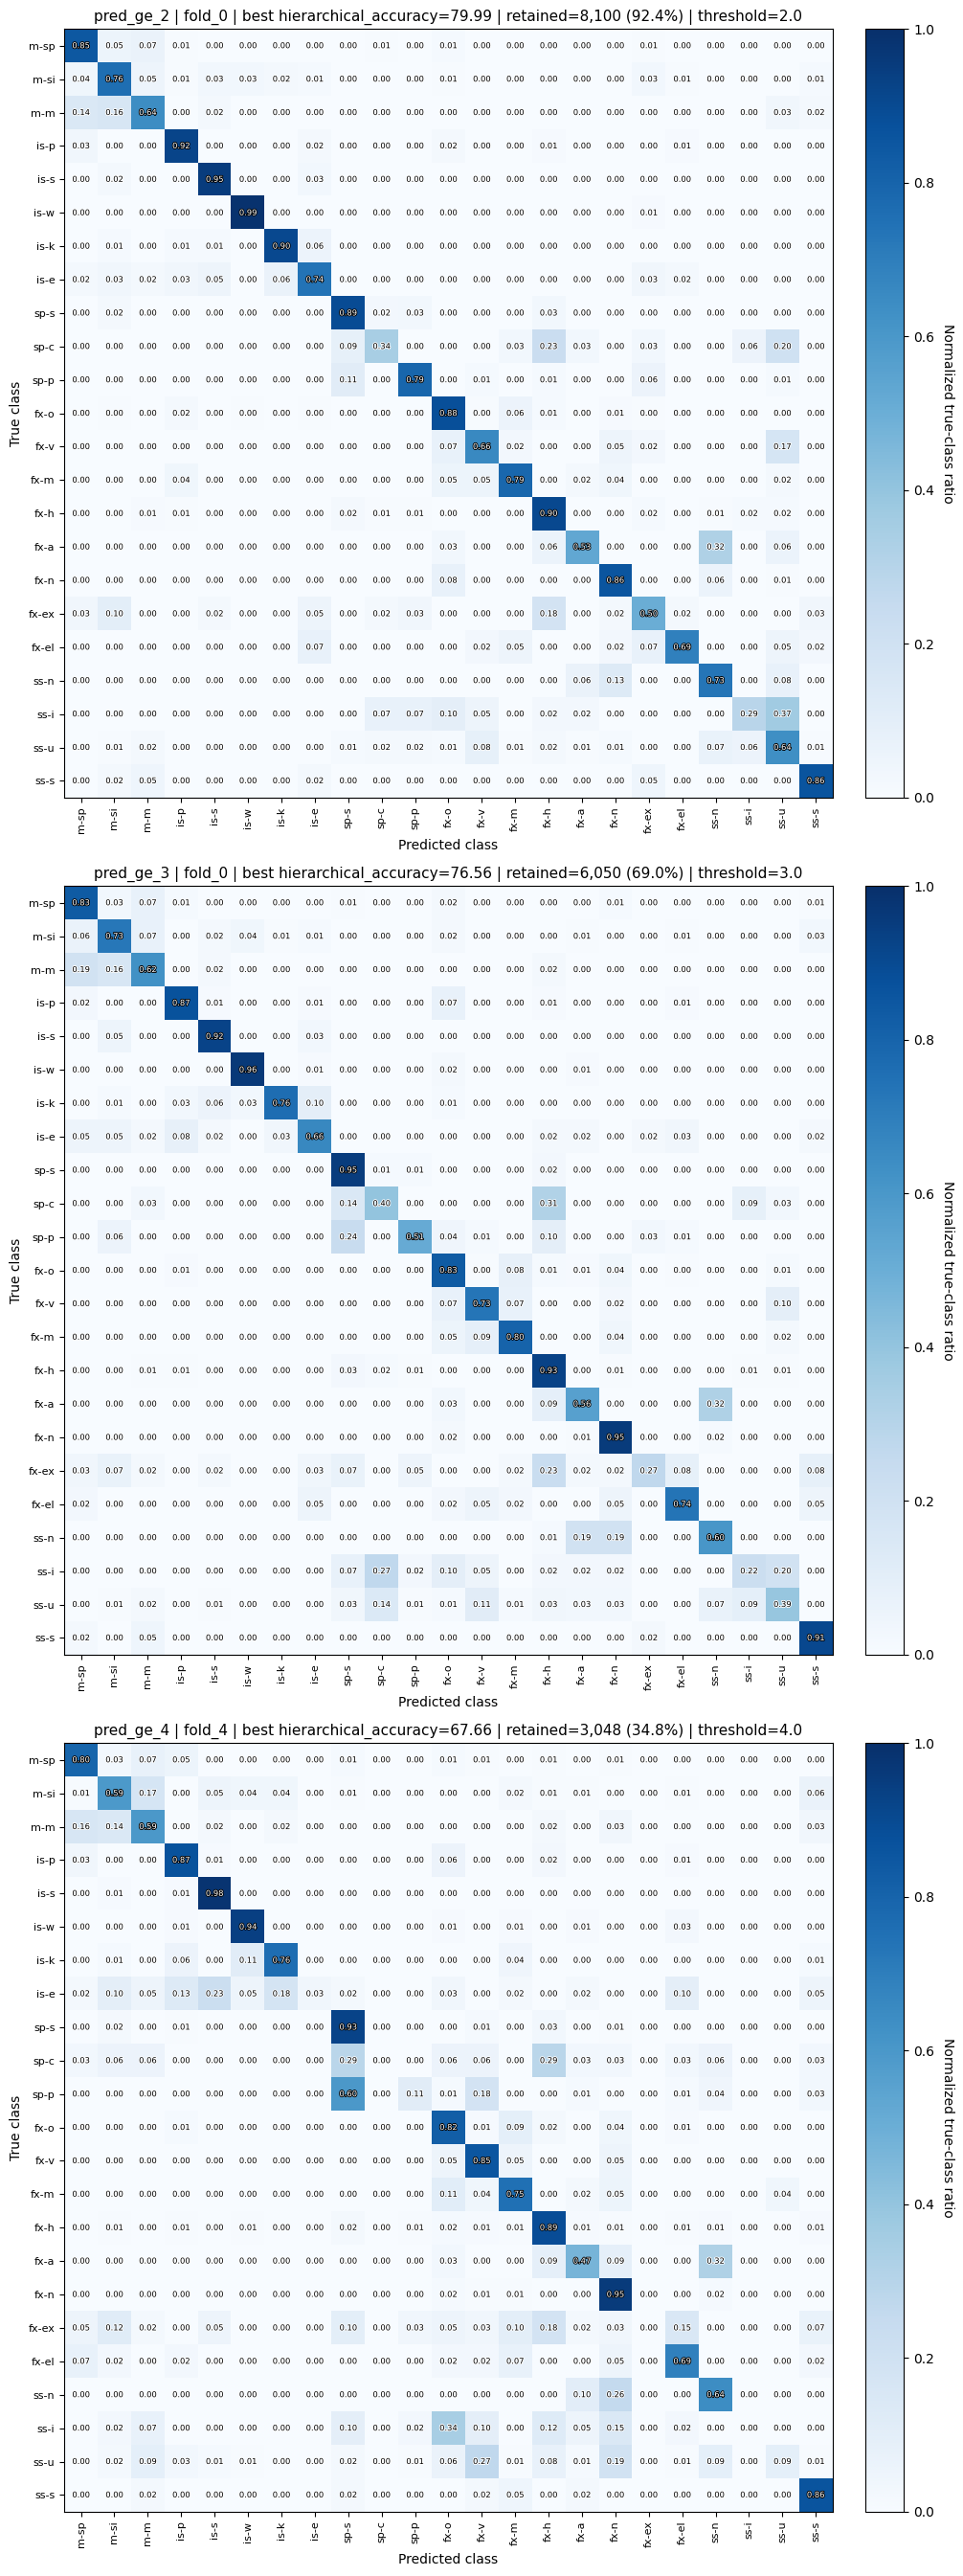


=== Best folds selected for confusion matrix ===
filter_label  threshold mode  split  retained_samples  retained_ratio  best_val_accuracy  accuracy  hierarchical_f1                                                                                             output_dir
   pred_ge_2        2.0 both fold_0              8100        0.924236          80.370370 80.291971        78.830827 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_2\both\fold_0
   pred_ge_3        3.0 both fold_0              6050        0.690324          87.685950 76.186131        74.362184 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_3\both\fold_0
   pred_ge_4        4.0 both fold_4              3048        0.347786          94.417077 67.518248        68.641168 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\pred_ge_4\both\fold_4

saved best-fold table: C:\Users\solok\Desktop\Dcase baseline\baseline_con

,filter_label,threshold,retained_samples,retained_ratio,mode,split,train_samples,val_samples,final_test_samples,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,pred_ge_2,2.0,8100,0.924236,both,fold_0,6480,1620,2192,80.370370,80.291971,89.416058,74.375116,79.986037,79.512542,78.583307,78.830827,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,pred_ge_2,2.0,8100,0.924236,both,fold_1,6480,1620,2192,82.777778,80.656934,89.324818,74.481837,79.811712,79.438483,78.479243,78.718453,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,pred_ge_2,2.0,8100,0.924236,both,fold_3,6480,1620,2192,81.358025,79.653285,89.233577,74.030321,79.661608,79.227172,78.253786,78.101764,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,pred_ge_2,2.0,8100,0.924236,both,fold_2,6480,1620,2192,81.604938,80.063869,88.731752,73.243288,78.806524,78.341249,77.415715,77.607351,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,pred_ge_2,2.0,8100,0.924236,both,fold_4,6480,1620,2192,81.604938,79.333942,89.279197,72.012755,78.198092,78.935513,76.651758,77.024585,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,pred_ge_3,3.0,6050,0.690324,both,fold_0,4840,1210,2192,87.685950,76.186131,86.678832,70.287527,76.564833,75.937042,74.995506,74.362184,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,pred_ge_3,3.0,6050,0.690324,both,fold_3,4840,1210,2192,88.760331,76.003650,86.724453,68.886235,75.676324,74.351231,73.978801,73.317713,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,pred_ge_3,3.0,6050,0.690324,both,fold_2,4840,1210,2192,87.272727,77.144161,86.633212,69.138638,75.452602,75.243512,73.874111,73.770485,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,pred_ge_3,3.0,6050,0.690324,both,fold_1,4840,1210,2192,87.355372,76.231752,86.541971,69.045117,75.446586,74.099654,73.846219,73.436455,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,pred_ge_3,3.0,6050,0.690324,both,fold_4,4840,1210,2192,86.694215,75.593066,86.222628,68.506948,75.047027,75.346675,73.412007,73.016980,c:\Users\solok\Desktop\Dcase baseline\baseline...


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir,fold_num
0,v3_binary_prob_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,8100,0.924236,2192,ok,...,80.291971,89.416058,74.375116,85.596959,79.986037,79.512542,78.583307,78.830827,c:\Users\solok\Desktop\Dcase baseline\baseline...,0.0
1,v3_binary_prob_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,6050,0.690324,2192,ok,...,76.186131,86.678832,70.287527,82.842138,76.564833,75.937042,74.995506,74.362184,c:\Users\solok\Desktop\Dcase baseline\baseline...,0.0
2,v3_binary_prob_scaled_to_1_5,pred_ge_4,predicted_confidence_score,4.0,4,8764,3048,0.347786,2192,ok,...,67.518248,81.021898,59.226547,76.083742,67.655144,71.255287,73.781980,68.641168,c:\Users\solok\Desktop\Dcase baseline\baseline...,4.0



=== Fold mean ± std by confidence threshold ===
source: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\summary_results.csv
saved summary: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v3_binary\fold_metric_summary_by_confidence.csv

confidence2:
  accuracy              : 80.00% ± 0.52%
  hierarchical_accuracy : 79.29% ± 0.76%
  hierarchical_f1       : 78.06% ± 0.76%
  hierarchical_precision: 79.09% ± 0.48%
  hierarchical_recall   : 77.88% ± 0.82%
  macro_accuracy        : 73.63% ± 1.03%
  macro_top_accuracy    : 84.96% ± 0.55%
  top_accuracy          : 89.20% ± 0.27%

confidence3:
  accuracy              : 76.23% ± 0.57%
  hierarchical_accuracy : 75.64% ± 0.57%
  hierarchical_f1       : 73.58% ± 0.51%
  hierarchical_precision: 75.00% ± 0.76%
  hierarchical_recall   : 74.02% ± 0.59%
  macro_accuracy        : 69.17% ± 0.67%
  macro_top_accuracy    : 82.10% ± 0.53%
  top_accuracy          : 86.56% ± 0.20%

confidence4:
  accuracy

,filter_label,mode,threshold,display_threshold,retained_samples,retained_ratio,final_test_samples,fold_count,accuracy_mean,accuracy_std,...,hierarchical_precision_mean,hierarchical_precision_std,hierarchical_recall_mean,hierarchical_recall_std,macro_accuracy_mean,macro_accuracy_std,macro_top_accuracy_mean,macro_top_accuracy_std,top_accuracy_mean,top_accuracy_std
0,pred_ge_2,both,2.0,2,8100,0.924236,2192,5,80.000000,0.520753,...,79.090992,0.475207,77.876762,0.824248,73.628663,1.025439,84.956926,0.554590,89.197080,0.268735
1,pred_ge_3,both,3.0,3,6050,0.690324,2192,5,76.231752,0.568885,...,74.995623,0.756465,74.021329,0.586182,69.172893,0.668125,82.102056,0.529793,86.560219,0.200419
2,pred_ge_4,both,4.0,4,3048,0.347786,2192,5,66.350365,0.946335,...,68.308691,2.170483,73.376801,1.656766,57.351499,1.425850,74.350424,1.226615,79.908759,0.710860


In [6]:
from pathlib import Path
import sys
import importlib

ROOT = Path(r"C:\Users\solok\Desktop\Dcase baseline")
sys.path.insert(0, str(ROOT))

import baseline_confidnce_train.confidence_baseline_common as cbc
importlib.reload(cbc)

all_results, best_folds, fig_path = cbc.show_v2_5class_results(
    output_root=ROOT / "baseline_confidnce_train" / "outputs" / "v3_binary"
)
display(all_results)
display(best_folds)
fig_path
cbc.summarize_folds_by_confidence(
    ROOT / "baseline_confidnce_train" / "outputs" / "v3_binary"
)